# 05: Phase Inconsistency, Pitch Dynamics & Vocal Perturbation Forensics

## 1. Research Scope & Objectives
This notebook investigates phase unwrapping, Modified Group Delay (MGD), fundamental frequency ($F_0$) pitch trajectories, and biomechanical vocal perturbation metrics (Jitter and Shimmer).

### Mathematical Formulations
Modified Group Delay:
$$\tau_g(\omega) = -\frac{d\theta(\omega)}{d\omega}$$
Period-to-Period Relative Jitter:
$$\text{Jitter}_{\text{local}} = \frac{\frac{1}{N-1}\sum_{i=1}^{N-1} |T_i - T_{i+1}|}{\frac{1}{N}\sum_{i=1}^N T_i}$$
Amplitude Shimmer:
$$\text{Shimmer}_{\text{local}} = \frac{\frac{1}{N-1}\sum_{i=1}^{N-1} |A_i - A_{i+1}|}{\frac{1}{N}\sum_{i=1}^N A_i}$$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import soundfile as sf, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, librosa
from src.utils.config import path_config

sns.set_theme(style="whitegrid")
manifest_path = os.path.join(path_config.data_processed, "protocol_manifest.parquet")
df = pd.read_parquet(manifest_path)

## 2. Phase Spectrum & Group Delay Dispersion
Neural vocoders approximate phase distributions, creating high-frequency group delay dispersion.

In [2]:
sample_bon = df[df.key == "bonafide"].iloc[0]["file_path"]
sample_spf = df[df.key == "spoof"].iloc[0]["file_path"]

y_b, sr = sf.read(sample_bon)
y_s, _ = sf.read(sample_spf)

stft_b = librosa.stft(y_b, n_fft=1024, hop_length=256)
stft_s = librosa.stft(y_s, n_fft=1024, hop_length=256)

phase_b = np.angle(stft_b)
phase_s = np.angle(stft_s)

c:\Users\tamimystic\.conda\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


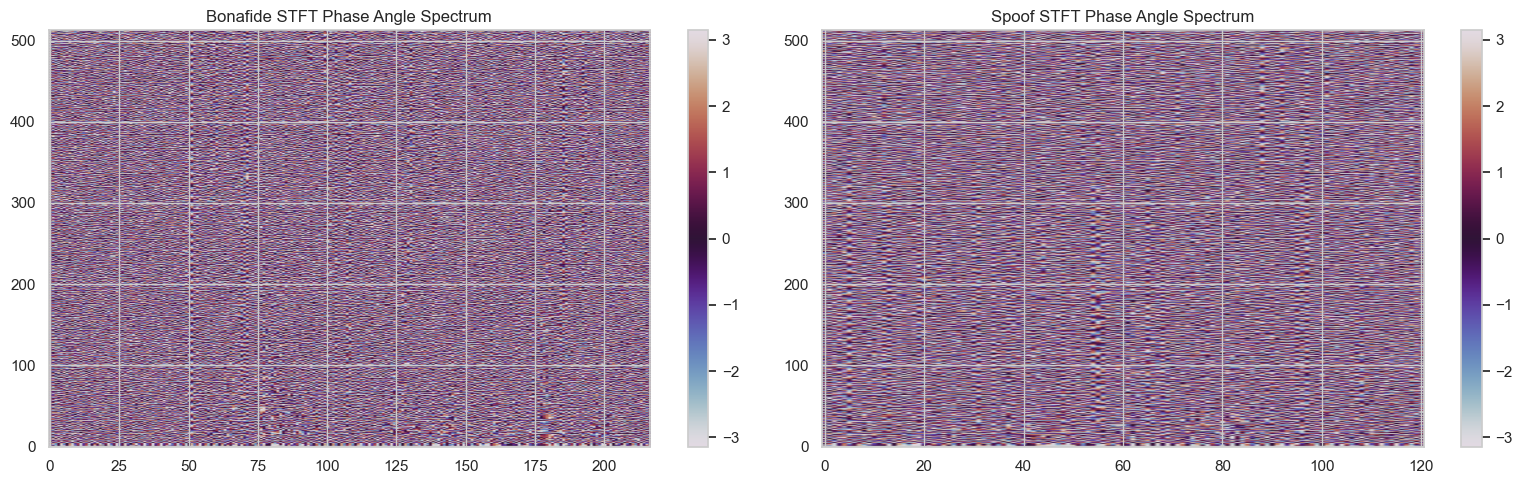

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
im1 = axes[0].imshow(phase_b, aspect="auto", origin="lower", cmap="twilight")
axes[0].set_title("Bonafide STFT Phase Angle Spectrum")
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(phase_s, aspect="auto", origin="lower", cmap="twilight")
axes[1].set_title("Spoof STFT Phase Angle Spectrum")
fig.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()

## 3. Fundamental Frequency ($F_0$) Pitch Trajectory Analysis
We extract continuous pitch contours via probabilistic YIN (pYIN) to measure robotic pitch flatness.

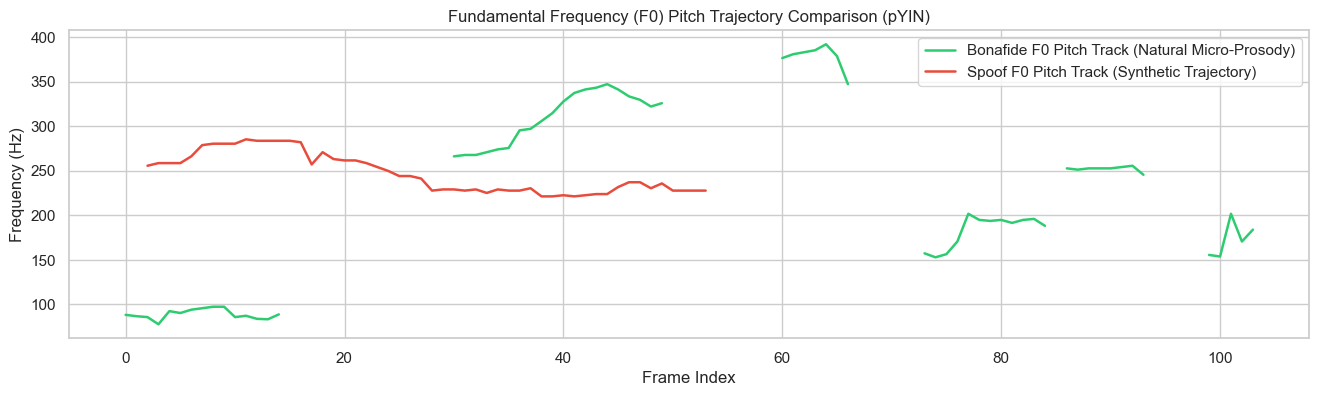

In [4]:
f0_b, voiced_b, probs_b = librosa.pyin(y_b, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"), sr=sr)
f0_s, voiced_s, probs_s = librosa.pyin(y_s, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"), sr=sr)

plt.figure(figsize=(16, 4))
plt.plot(f0_b, label="Bonafide F0 Pitch Track (Natural Micro-Prosody)", color="#2ecc71", lw=1.8)
plt.plot(f0_s, label="Spoof F0 Pitch Track (Synthetic Trajectory)", color="#e74c3c", lw=1.8)
plt.title("Fundamental Frequency (F0) Pitch Trajectory Comparison (pYIN)")
plt.xlabel("Frame Index")
plt.ylabel("Frequency (Hz)")
plt.legend()
plt.show()

## 4. Vocal Perturbation Analysis (Jitter & Shimmer Metrics)

In [5]:
def calculate_perturbations(y):
    peaks = np.where((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]) & (y[1:-1] > 0.1))[0] + 1
    if len(peaks) < 4:
        return 0.0, 0.0
    periods = np.diff(peaks)
    amplitudes = y[peaks]
    jitter = np.mean(np.abs(np.diff(periods))) / (np.mean(periods) + 1e-7)
    shimmer = np.mean(np.abs(np.diff(amplitudes))) / (np.mean(amplitudes) + 1e-7)
    return float(jitter), float(shimmer)

bon_paths = df[(df.split=="train") & (df.key=="bonafide")]["file_path"].head(60)
spf_paths = df[(df.split=="train") & (df.key=="spoof")]["file_path"].head(60)

pert_records = []
for p in bon_paths:
    y, sr = sf.read(p)
    j, s = calculate_perturbations(y)
    pert_records.append({"jitter": j, "shimmer": s, "key": "bonafide"})
for p in spf_paths:
    y, sr = sf.read(p)
    j, s = calculate_perturbations(y)
    pert_records.append({"jitter": j, "shimmer": s, "key": "spoof"})

pert_df = pd.DataFrame(pert_records)

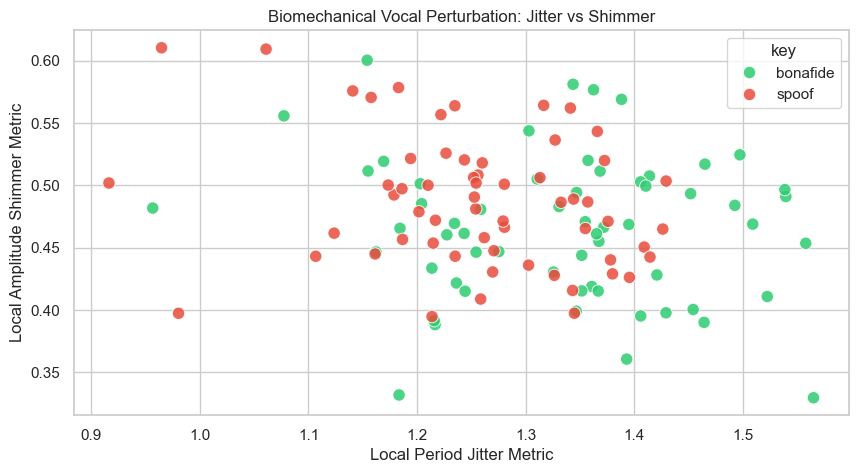

In [6]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=pert_df, x="jitter", y="shimmer", hue="key", palette=["#2ecc71", "#e74c3c"], s=80, alpha=0.85)
plt.title("Biomechanical Vocal Perturbation: Jitter vs Shimmer")
plt.xlabel("Local Period Jitter Metric")
plt.ylabel("Local Amplitude Shimmer Metric")
plt.show()